In [2]:

from google.colab import files

uploaded = files.upload()

Saving earthquake_1995-2023.csv to earthquake_1995-2023.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("earthquake_1995-2023.csv")

print("Dataset Shape:", df.shape)
print("\nFirst 5 Records:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (1000, 19)

First 5 Records:


,title,magnitude,date_time,cdi,mmi,alert,tsunami,sig,net,nst,dmin,gap,magType,depth,latitude,longitude,location,continent,country
0,"M 6.5 - 42 km W of Sola, Vanuatu",6.5,16-08-2023 12:47,7,4,green,0,657,us,114,7.177000,25.0,mww,192.955,-13.8814,167.1580,"Sola, Vanuatu",NaN,Vanuatu
1,"M 6.5 - 43 km S of Intipucá, El Salvador",6.5,19-07-2023 00:22,8,6,yellow,0,775,us,92,0.679000,40.0,mww,69.727,12.8140,-88.1265,"Intipucá, El Salvador",NaN,NaN
2,"M 6.6 - 25 km ESE of Loncopué, Argentina",6.6,17-07-2023 03:05,7,5,green,0,899,us,70,1.634000,28.0,mww,171.371,-38.1911,-70.3731,"Loncopué, Argentina",South America,Argentina
3,"M 7.2 - 98 km S of Sand Point, Alaska",7.2,16-07-2023 06:48,6,6,green,1,860,us,173,0.907000,36.0,mww,32.571,54.3844,-160.6990,"Sand Point, Alaska",NaN,NaN
4,M 7.3 - Alaska Peninsula,7.3,16-07-2023 06:48,0,5,NaN,1,820,at,79,0.879451,172.8,Mi,21.000,54.4900,-160.7960,Alaska Peninsula,NaN,NaN



Data Types:
title         object
magnitude    float64
date_time     object
cdi            int64
mmi            int64
alert         object
tsunami        int64
sig            int64
net           object
nst            int64
dmin         float64
gap          float64
magType       object
depth        float64
latitude     float64
longitude    float64
location      object
continent     object
country       object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   title      1000 non-null   object 
 1   magnitude  1000 non-null   float64
 2   date_time  1000 non-null   object 
 3   cdi        1000 non-null   int64  
 4   mmi        1000 non-null   int64  
 5   alert      449 non-null    object 
 6   tsunami    1000 non-null   int64  
 7   sig        1000 non-null   int64  
 8   net        1000 non-null   object 
 9   n

In [4]:
full_duplicates = df.duplicated().sum()
key_duplicates = df.duplicated(subset=["title", "date_time"]).sum()

print("Fully identical duplicates:", full_duplicates)
print("Duplicate earthquakes using title + date_time:", key_duplicates)

before = len(df)

df = df.drop_duplicates()
df = df.drop_duplicates(subset=["title", "date_time"])

after = len(df)

print("\nRows before removal:", before)
print("Rows after removal:", after)
print("Rows removed:", before - after)

Fully identical duplicates: 0
Duplicate earthquakes using title + date_time: 2

Rows before removal: 1000
Rows after removal: 998
Rows removed: 2


In [5]:
missing_report = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_report)

zero_columns = ["cdi", "gap", "nst", "dmin"]

print("Zero values before conversion:")
print((df[zero_columns] == 0).sum())

for column in zero_columns:
    df[column] = df[column].replace(0, np.nan)

print("\nMissing values after converting zero placeholders:")
print(df[zero_columns].isnull().sum())

,Missing Count,Missing Percentage
title,0,0.00
magnitude,0,0.00
date_time,0,0.00
cdi,0,0.00
mmi,0,0.00
alert,549,55.01
tsunami,0,0.00
sig,0,0.00
net,0,0.00
nst,0,0.00


Zero values before conversion:
cdi     395
gap     252
nst     519
dmin    586
dtype: int64

Missing values after converting zero placeholders:
cdi     395
gap     252
nst     519
dmin    586
dtype: int64


Skewness of CDI: -0.323
Skewness of Dmin: 2.0


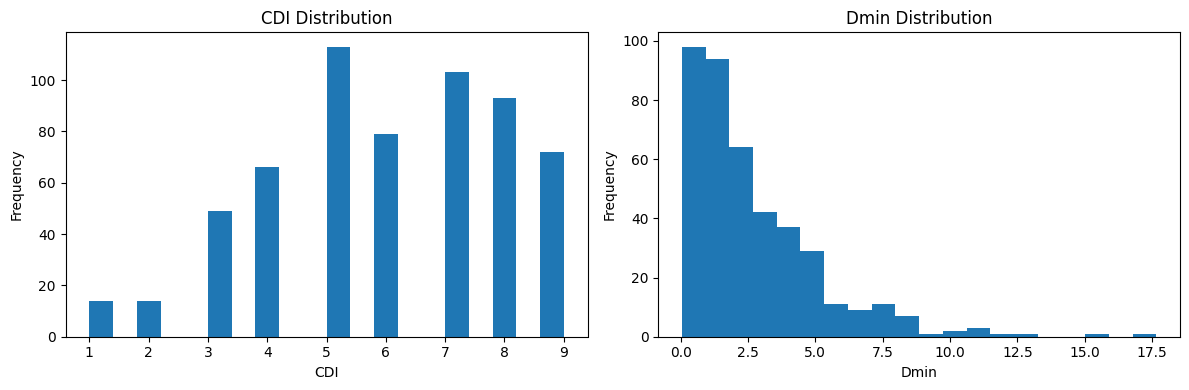

In [6]:
print("Skewness of CDI:", round(df["cdi"].skew(), 3))
print("Skewness of Dmin:", round(df["dmin"].skew(), 3))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(df["cdi"].dropna(), bins=20)
plt.xlabel("CDI")
plt.ylabel("Frequency")
plt.title("CDI Distribution")

plt.subplot(1, 2, 2)
plt.hist(df["dmin"].dropna(), bins=20)
plt.xlabel("Dmin")
plt.ylabel("Frequency")
plt.title("Dmin Distribution")

plt.tight_layout()
plt.show()

In [7]:
cdi_mean = df["cdi"].mean()
dmin_median = df["dmin"].median()

print("CDI mean:", round(cdi_mean, 3))
print("Dmin median:", round(dmin_median, 3))

df["cdi"] = df["cdi"].fillna(cdi_mean)
df["dmin"] = df["dmin"].fillna(dmin_median)

print("\nCDI missing values after imputation:", df["cdi"].isnull().sum())
print("Dmin missing values after imputation:", df["dmin"].isnull().sum())

CDI mean: 5.978
Dmin median: 1.992

CDI missing values after imputation: 0
Dmin missing values after imputation: 0


In [8]:
print("Missing values before categorical treatment:")
print(df[["alert", "location", "continent", "country"]].isnull().sum())

df["alert"] = df["alert"].fillna(df["alert"].mode()[0])

for column in ["location", "continent", "country"]:
    df[column] = df[column].fillna("Unknown")

print("\nMissing values after categorical treatment:")
print(df[["alert", "location", "continent", "country"]].isnull().sum())

Missing values before categorical treatment:
alert        549
location       6
continent    714
country      347
dtype: int64

Missing values after categorical treatment:
alert        0
location     0
continent    0
country      0
dtype: int64


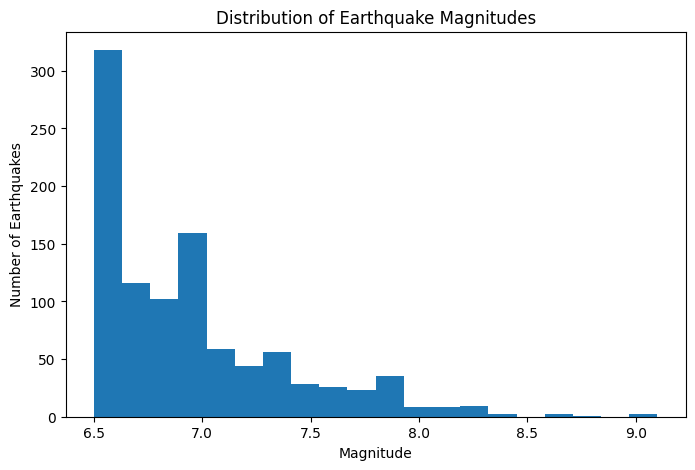

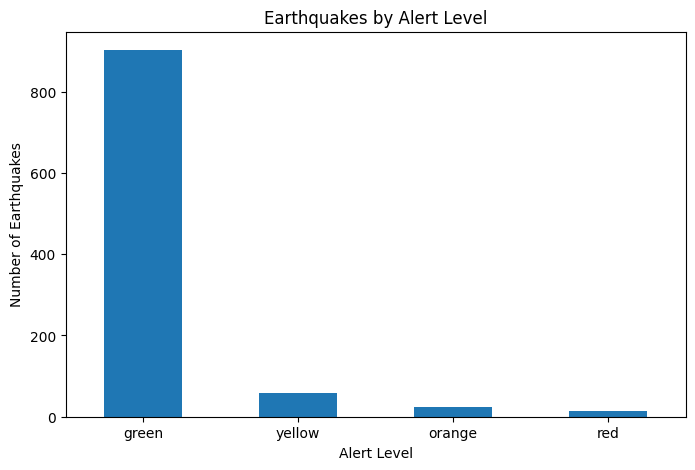

Total remaining missing values: 771
Final dataset shape: (998, 19)


In [9]:
plt.figure(figsize=(8, 5))
plt.hist(df["magnitude"].dropna(), bins=20)
plt.xlabel("Magnitude")
plt.ylabel("Number of Earthquakes")
plt.title("Distribution of Earthquake Magnitudes")
plt.show()

plt.figure(figsize=(8, 5))
df["alert"].value_counts().plot(kind="bar")
plt.xlabel("Alert Level")
plt.ylabel("Number of Earthquakes")
plt.title("Earthquakes by Alert Level")
plt.xticks(rotation=0)
plt.show()

print("Total remaining missing values:", df.isnull().sum().sum())
print("Final dataset shape:", df.shape)